Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-0.5 pkt] Użyj zbalansowania klas w regresji logistycznej (parametr `class_weight`). Porównaj z modelem podstawowym
1. [0-1 pkt] Porównaj różne techniki podpróbkownia (*undersampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Podpróbkowanie losowe
   2. [Cluster Centroids](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.ClusterCentroids.html#clustercentroids)
   3. *Edited Nearest Neighbours* (patrz ćwiczenia) 
1. [0-2 pkt] Porównaj różne techniki nadpróbkowania (*oversampling*). W szczególności (weź pod uwagę hiperparametry każdego podejścia!):
   1. Nadpróbkowanie losowe
   2. [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
   3. [Borderline SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html#)
   3. [ADASYN](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html)
1. [0-1 pkt] Przeprowadź dostrajanie progu (*threshold tuning*) tj. użyj innych progów odcięcia klasy pozytywnej w regresji logistycznej. Możesz wykorzystać np. metody opisane [tutaj](https://scikit-learn.org/stable/modules/classification_threshold.html). Optymalizuj względem AUPRC
1. [0-1 pkt] Użyj przynajmniej jednego innego klasyfikatora poznanego na zajęciach i porównaj jego wyniki z regresją logistyczną
1. [0-1.5 pkt] Zaimplementuj fokalną funkcję kosztu (*focal loss*) w `scikit-learn`. W tym celu, wyjątkowo, **możesz skorzystać z narzędzi generatywnej sztucznej inteligencji**
1. [0-2 pkt] Sporządź analizę porównawczą technik / modeli wyżej, uwzględniając podejścia podstawowe (*baseline*). Zwizualizuj krzywe ROC i PRC
1. [0-1 pkt] Skomentuj uzyskane wyniki

## Preprocessing danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, precision_score, recall_score, f1_score

sklearn.set_config(transform_output="pandas")

bank_marketing = fetch_ucirepo(id=222) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets['y'] 

X_sel = X[['balance', 'duration', 'education']]

idx = X_sel.dropna().index
X_sel = X_sel.loc[idx]
y_sel = y.loc[idx]

label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y_sel.values)

enc = OneHotEncoder(drop='first', sparse_output=False)
X_trans = X_sel.drop(columns=['education']).join(
    enc.fit_transform(X_sel[['education']]))

X_train, X_test, y_train, y_test = train_test_split(X_trans, y_trans,
                                                    test_size=0.2, random_state=0)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (34683, 4), X_test shape: (8671, 4)


## Zadanie 1


In [2]:
model_baseline = LogisticRegression(random_state=0, max_iter=1000)
model_baseline.fit(X_train, y_train)

model_balanced = LogisticRegression(random_state=0, class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train, y_train)

y_test_pred_base = model_baseline.predict(X_test)
y_test_prob_base = model_baseline.predict_proba(X_test)[:, 1]

y_test_pred_bal = model_balanced.predict(X_test)
y_test_prob_bal = model_balanced.predict_proba(X_test)[:, 1]

print("Regresja logistyczna")
print(f"Precision: {precision_score(y_test, y_test_pred_base):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_base):.4f}")
print(f"F1: {f1_score(y_test, y_test_pred_base):.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_test_pred_base))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob_base):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_test_prob_base):.4f}")

print("\nRegresja logistyczna z class_weight='balanced'")
print(f"Precision: {precision_score(y_test, y_test_pred_bal):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_bal):.4f}")
print(f"F1: {f1_score(y_test, y_test_pred_bal):.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_test_pred_bal))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob_bal):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_test_prob_bal):.4f}")


Regresja logistyczna
Precision: 0.5580
Recall: 0.1573
F1: 0.2454
Macierz pomyłek:
[[7570  122]
 [ 825  154]]
ROC AUC: 0.8149
AUPRC: 0.3762

Regresja logistyczna z class_weight='balanced'
Precision: 0.3053
Recall: 0.6496
F1: 0.4154
Macierz pomyłek:
[[6245 1447]
 [ 343  636]]
ROC AUC: 0.8170
AUPRC: 0.3764


Model bazowy faworyzuje klase dominującą, co daje względnie dobre wyniki ogólne, ale w praktyce prowadzi do niskiej wykrywalnosci klasy pozytywnej (niski `recall`) i slabszego `f1`

Po zastosowaniu wyważenia klas wyraznie rosną `recall` i `f1`, co oznacza, ze model znacznie lepiej wychwytuje przypadki pozytywne kosztem spadku `precision`

W kontekście takich danych bardziej preferowane są rozwiązania z wyższym `recall`/`f1` (mniejsze ryzyko pomijania pozytywnych przypadkow), a wybór progu można dalej dostroić w zależności od kosztów błędów

## Zadanie 2


In [10]:
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, EditedNearestNeighbours
from sklearn.cluster import MiniBatchKMeans

under_samplers = {
    'RandomUnderSampler': RandomUnderSampler(random_state=0),
    'ClusterCentroids': ClusterCentroids(estimator=MiniBatchKMeans(n_init='auto', random_state=0), random_state=0),
    'EditedNearestNeighbours': EditedNearestNeighbours()
}

under_results = {}

for name, sampler in under_samplers.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    
    model = LogisticRegression(random_state=0, max_iter=1000)
    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    under_results[name] = {
        'model': model,
        'X_res': X_res,
        'y_res': y_res,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'auprc': average_precision_score(y_test, y_prob),
        'cm': confusion_matrix(y_test, y_pred)
    }

for name, res in under_results.items():
    print(f"\n{name}")
    print(f"Klasa 0: {sum(res['y_res']==0)} próbek, klasa 1: {sum(res['y_res']==1)} próbek")
    print(f"Precision: {res['precision']:.4f}")
    print(f"Recall: {res['recall']:.4f}")
    print(f"F1: {res['f1']:.4f}")
    print("Macierz pomyłek:")
    print(res['cm'])
    print(f"ROC AUC: {res['roc_auc']:.4f}")
    print(f"AUPRC: {res['auprc']:.4f}")



RandomUnderSampler
Klasa 0: 4058 próbek, klasa 1: 4058 próbek
Precision: 0.3016
Recall: 0.6476
F1: 0.4116
Macierz pomyłek:
[[6224 1468]
 [ 345  634]]
ROC AUC: 0.8168
AUPRC: 0.3736

ClusterCentroids
Klasa 0: 4058 próbek, klasa 1: 4058 próbek
Precision: 0.3055
Recall: 0.6353
F1: 0.4126
Macierz pomyłek:
[[6278 1414]
 [ 357  622]]
ROC AUC: 0.8064
AUPRC: 0.3723

EditedNearestNeighbours
Klasa 0: 23701 próbek, klasa 1: 4058 próbek
Precision: 0.4310
Recall: 0.4147
F1: 0.4227
Macierz pomyłek:
[[7156  536]
 [ 573  406]]
ROC AUC: 0.8192
AUPRC: 0.3783


Wyniki pokazuja, jak poszczególny sposób undersamplingu wpływa na dane oraz model

**RandomUnderSampler** silnie wyrównuje klasy, co podnosi `recall`, ale obcina `precision`

**ClusterCentroids** poprzez klasteryzację prowadzi do gorszego odwzorowania granicy decyzyjnej. W efekcie spadają metryki ROC AUC/AUPRC i pogarsza się równowaga `precision`/`recall`

**EditedNearestNeighbours** usuwa próbki przy granicy decyzyjnej, ale nie dąży do idealnego balansu 50/50. Zostawienie większej części danych treningowych zwykle poprawia `precision` i stabilizuje ROC AUC/AUPRC, kosztem nizszego `recall`

W tym kontekscie naszego datasetu, spośród metod podpróbkowania, najlepszy jest **RandomUnderSampler**, bo zwykle maksymalizuje `recall` (i zapewnia sensowny `f1`) kosztem niskiej `precision`

## Zadanie 3

In [11]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN

over_samplers = {
    'RandomOverSampler': RandomOverSampler(random_state=0),
    'SMOTE': SMOTE(random_state=0),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=0),
    'ADASYN': ADASYN(random_state=0)
}

over_results = {}

for name, sampler in over_samplers.items():
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    
    model = LogisticRegression(random_state=0, max_iter=1000)
    model.fit(X_res, y_res)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    over_results[name] = {
        'model': model,
        'X_res': X_res,
        'y_res': y_res,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'auprc': average_precision_score(y_test, y_prob),
        'cm': confusion_matrix(y_test, y_pred)
    }

for name, res in over_results.items():
    print(f"\n{name}")
    print(f"Liczba próbek po resamplingu: {len(res['y_res'])} (klasa 0: {sum(res['y_res']==0)}, klasa 1: {sum(res['y_res']==1)})")
    print(f"Precision: {res['precision']:.4f}")
    print(f"Recall: {res['recall']:.4f}")
    print(f"F1: {res['f1']:.4f}")
    print("Macierz pomyłek:")
    print(res['cm'])
    print(f"ROC AUC: {res['roc_auc']:.4f}")
    print(f"AUPRC: {res['auprc']:.4f}")



RandomOverSampler
Liczba próbek po resamplingu: 61250 (klasa 0: 30625, klasa 1: 30625)
Precision: 0.3047
Recall: 0.6496
F1: 0.4149
Macierz pomyłek:
[[6241 1451]
 [ 343  636]]
ROC AUC: 0.8171
AUPRC: 0.3767

SMOTE
Liczba próbek po resamplingu: 61250 (klasa 0: 30625, klasa 1: 30625)
Precision: 0.3004
Recall: 0.6527
F1: 0.4115
Macierz pomyłek:
[[6204 1488]
 [ 340  639]]
ROC AUC: 0.8147
AUPRC: 0.3753

BorderlineSMOTE
Liczba próbek po resamplingu: 61250 (klasa 0: 30625, klasa 1: 30625)
Precision: 0.2996
Recall: 0.6619
F1: 0.4125
Macierz pomyłek:
[[6177 1515]
 [ 331  648]]
ROC AUC: 0.8171
AUPRC: 0.3756

ADASYN
Liczba próbek po resamplingu: 60574 (klasa 0: 30625, klasa 1: 29949)
Precision: 0.2887
Recall: 0.6874
F1: 0.4066
Macierz pomyłek:
[[6034 1658]
 [ 306  673]]
ROC AUC: 0.8124
AUPRC: 0.3742


Nadpróbkowanie nie usuwa danych klasy większościowej, dlatego wyniki są stabilniejsze niż przy undersamplingu i metryki `recall`/`f1` zwykle rosną

**RandomOverSampler, SMOTE i Borderline SMOTE** dają zbliżone rezultaty: `recall` jest wysoki i porównywalny między metodami, a `precision` umiarkowana, co przekłada się na podobny `f1`

**ADASYN** maksymalizuje klasę pozytywną, dlatego osiąga najwyższy `recall`, ale za to otrzymujemy mniejsze `precision`

## Zadanie 4

In [13]:
from sklearn.model_selection import TunedThresholdClassifierCV

tuned_model_ap = TunedThresholdClassifierCV(
    estimator=LogisticRegression(random_state=0, max_iter=1000),
    scoring='average_precision',
    cv=5
)
tuned_model_ap.fit(X_train, y_train)

y_pred_tuned_ap = tuned_model_ap.predict(X_test)
y_prob_tuned_ap = tuned_model_ap.predict_proba(X_test)[:, 1]


print(f"Zoptymalizowany próg: {tuned_model_ap.best_threshold_:.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned_ap):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned_ap):.4f}")
print(f"F1: {f1_score(y_test, y_pred_tuned_ap):.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_tuned_ap))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_tuned_ap):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_tuned_ap):.4f}")


Zoptymalizowany próg: 0.2115
Precision: 0.4212
Recall: 0.4147
F1: 0.4179
Macierz pomyłek:
[[7134  558]
 [ 573  406]]
ROC AUC: 0.8149
AUPRC: 0.3762


**Optymalizacja pod AUPRC** dobiera prog tak, aby maksymalizowac jakość w klasie pozytywnej, co zwykle zwiększa `recall` kosztem `precision`

W przypdku naszego datasetu taka optymalizacja ma sens, bo zależy nam na poprawie wykrywalnosci klasy pozytywnej przy akceptowalnym spadku precyzji

## Zadanie 5

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=0, n_estimators=100, max_depth=10)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classifier")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1: {f1_score(y_test, y_pred_rf):.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_rf):.4f}")


Random Forest Classifier
Precision: 0.5378
Recall: 0.1818
F1: 0.2718
Macierz pomyłek:
[[7539  153]
 [ 801  178]]
ROC AUC: 0.8300
AUPRC: 0.3808


Random Forest poprawia jakość predykcji (wyższe `ROC AUC` i `AUPRC`) w porównaniu do regresji logistycznej

Jednoczesnie domyślny próg **0.5** utrzymuje wysokie `precision`, ale powoduje niski `recall`, co oznacza, ze model rzadziej wykrywa klasę pozytywną

## Zadanie 6

In [ ]:
import numpy as np
from scipy.optimize import minimize
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

class FocalLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, gamma=2.0, alpha=0.25, C=1.0, max_iter=1000):
        self.gamma = gamma
        self.alpha = alpha
        self.C = C
        self.max_iter = max_iter

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _focal_loss_and_grad(self, weights, X, y):
        z = X @ weights
        p = self._sigmoid(z)
        p = np.clip(p, 1e-15, 1 - 1e-15)
        
        pt = np.where(y == 1, p, 1 - p)
        alpha_t = np.where(y == 1, self.alpha, 1 - self.alpha)
        loss = -alpha_t * (1 - pt)**self.gamma * np.log(pt)
        mean_loss = np.mean(loss)
        
        reg_loss = 0.5 * (1.0 / self.C) * np.sum(weights[1:]**2)
        total_loss = mean_loss + reg_loss
        
        grad_z = np.where(y == 1,
                          self.alpha * (1 - p)**self.gamma * (self.gamma * p * np.log(p) - (1 - p)),
                          (1 - self.alpha) * p**self.gamma * (-self.gamma * (1 - p) * np.log(1 - p) + p))
        
        grad_weights = (X.T @ grad_z) / X.shape[0]
        
        reg_grad = np.zeros_like(weights)
        reg_grad[1:] = (1.0 / self.C) * weights[1:]
        
        total_grad = grad_weights + reg_grad
        
        return total_loss, total_grad

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = np.unique(y)
        
        X_design = np.c_[np.ones(X.shape[0]), X]
        initial_weights = np.zeros(X_design.shape[1])
        
        res = minimize(
            fun=self._focal_loss_and_grad,
            x0=initial_weights,
            args=(X_design, y),
            method='L-BFGS-B',
            jac=True,
            options={'maxiter': self.max_iter}
        )
        
        self.intercept_ = np.array([res.x[0]])
        self.coef_ = res.x[1:].reshape(1, -1)
        self.is_fitted_ = True
        return self

    def predict_proba(self, X):
        check_is_fitted(self)
        X = check_array(X)
        z = X @ self.coef_.T + self.intercept_
        prob = self._sigmoid(z).flatten()
        return np.c_[1 - prob, prob]

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

focal_model = FocalLogisticRegression(gamma=2.0, alpha=0.25, C=1.0)
focal_model.fit(X_train.values, y_train)

y_pred_focal = focal_model.predict(X_test.values)
y_prob_focal = focal_model.predict_proba(X_test.values)[:, 1]

print("Regresja logistyczna z Focal Loss")
print(f"Precision: {precision_score(y_test, y_pred_focal):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_focal):.4f}")
print(f"F1: {f1_score(y_test, y_pred_focal):.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_focal))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_focal):.4f}")
print(f"AUPRC: {average_precision_score(y_test, y_prob_focal):.4f}")


Regresja logistyczna z Focal Loss
Precision: 0.6032
Recall: 0.0388
F1: 0.0729
Macierz pomyłek:
[[7667   25]
 [ 941   38]]
ROC AUC: 0.8132
AUPRC: 0.3715


Model z `Focal loss` ma tendencje do skupiania się na trudniejszych przykładach, ale przy naszych ustawieniach $\gamma = 2.0$ i $\alpha = 0.25$ nie jest aż tak agresywny

W praktyce oznacza to wysokie `precision` przy niskim `recall`, co przekłada się na słabsze `f1` w porównaniu do metod resamplingu lub zmiany progu

Niski `recall` wynika z tego, że mała waga klasy pozytywnej (niskie $\alpha$) ogranicza liczbe wykrywanych pozytywnych klas.
Aby poprawić równowagę, należy zwiększyć $\alpha$ lub zmniejszyć $\gamma$, tak aby model agresywniej podchodził do łatwych przykładów

## Zadanie 7 i 8


,Model,ROC AUC,AUPRC,F1-score,Precision,Recall
0,Baseline (0.5),0.8149,0.3762,0.2454,0.5580,0.1573
1,Balanced (class_weight),0.8170,0.3764,0.4154,0.3053,0.6496
2,Under: Random,0.8168,0.3736,0.4116,0.3016,0.6476
3,Under: Cluster Centroids,0.8064,0.3723,0.4126,0.3055,0.6353
4,Under: ENN,0.8192,0.3783,0.4227,0.4310,0.4147
5,Over: Random,0.8171,0.3767,0.4149,0.3047,0.6496
6,Over: SMOTE,0.8147,0.3753,0.4115,0.3004,0.6527
7,Over: Borderline SMOTE,0.8171,0.3756,0.4125,0.2996,0.6619
8,Over: ADASYN,0.8124,0.3742,0.4066,0.2887,0.6874
9,Tuned Threshold (AP),0.8149,0.3762,0.4179,0.4212,0.4147


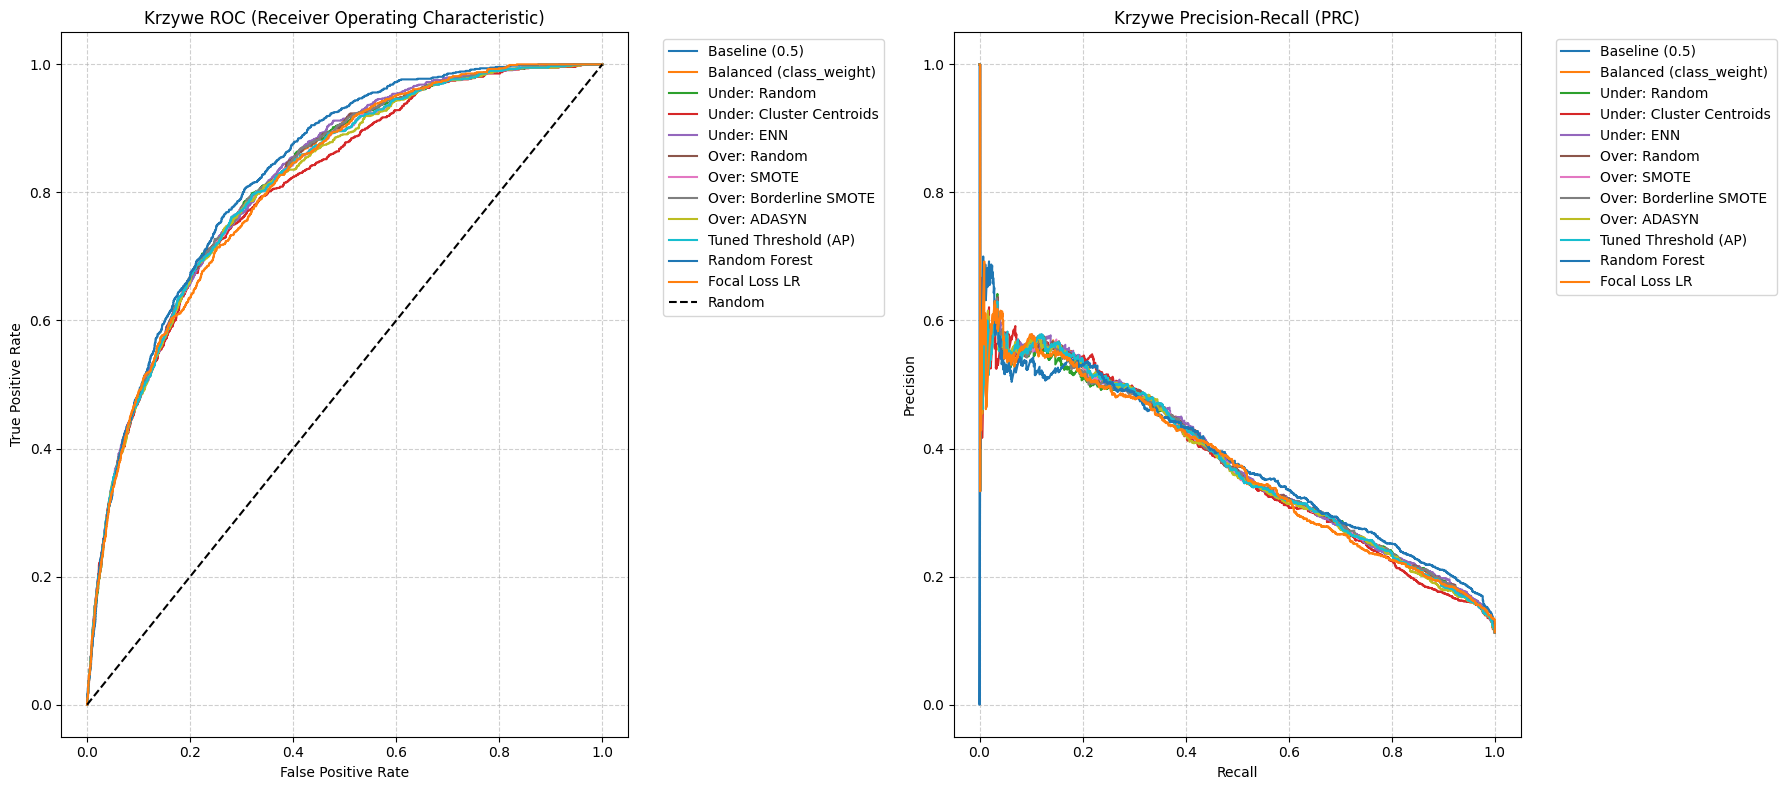

In [18]:
from sklearn.metrics import recall_score, precision_score, f1_score

models_eval = {
    'Baseline (0.5)': (y_test_pred_base, y_test_prob_base),
    'Balanced (class_weight)': (y_test_pred_bal, y_test_prob_bal),
    'Under: Random': (under_results['RandomUnderSampler']['y_pred'], under_results['RandomUnderSampler']['y_prob']),
    'Under: Cluster Centroids': (under_results['ClusterCentroids']['y_pred'], under_results['ClusterCentroids']['y_prob']),
    'Under: ENN': (under_results['EditedNearestNeighbours']['y_pred'], under_results['EditedNearestNeighbours']['y_prob']),
    'Over: Random': (over_results['RandomOverSampler']['y_pred'], over_results['RandomOverSampler']['y_prob']),
    'Over: SMOTE': (over_results['SMOTE']['y_pred'], over_results['SMOTE']['y_prob']),
    'Over: Borderline SMOTE': (over_results['BorderlineSMOTE']['y_pred'], over_results['BorderlineSMOTE']['y_prob']),
    'Over: ADASYN': (over_results['ADASYN']['y_pred'], over_results['ADASYN']['y_prob']),
    'Tuned Threshold (AP)': (y_pred_tuned_ap, y_prob_tuned_ap),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'Focal Loss LR': (y_pred_focal, y_prob_focal)
}

metrics_list = []
for name, (pred, prob) in models_eval.items():
    metrics_list.append({
        'Model': name,
        'ROC AUC': roc_auc_score(y_test, prob),
        'AUPRC': average_precision_score(y_test, prob),
        'F1-score': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred)
    })

df_metrics = pd.DataFrame(metrics_list)
display(df_metrics.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for name, (pred, prob) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=name)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('Krzywe ROC (Receiver Operating Characteristic)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.6)

for name, (pred, prob) in models_eval.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(recall, precision, label=name)
axes[1].set_title('Krzywe Precision-Recall (PRC)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Zestawienie metryk i krzywych `ROC/PRC` pokazuje, ze modele logistyczne osiągają podobne rezultaty, natomiast większy wpływ na nacisk kładziony przez model mają resampling i ustawianie progu

Najlepszą jakość metryk ROC AUC/AUPRC osiągają bardziej złożone modele, ale bez zmiany progu wciąż widac niski `recall` przy domyslnym **0.5**

Metody oversamplingu pozowują większą wykrywalność klasy pozytywnej, kosztem spadku `precision`, co jest widoczne na krzywych `PRC`.

Tuning progu pod `AUPRC` daje wzrost `recall`, dlatego jest sensownym wyborem przy niezbalansowanych klasach